### Dependencies

In [1]:
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import warnings
warnings.filterwarnings('default')

### Exercise 1

X shape: (500, 3)
Eigen Values: [10.9209405   3.4170854   0.41602862]
Eigen Vectors Shape: (3, 3)
First Eigen Vector Shape: (3,)


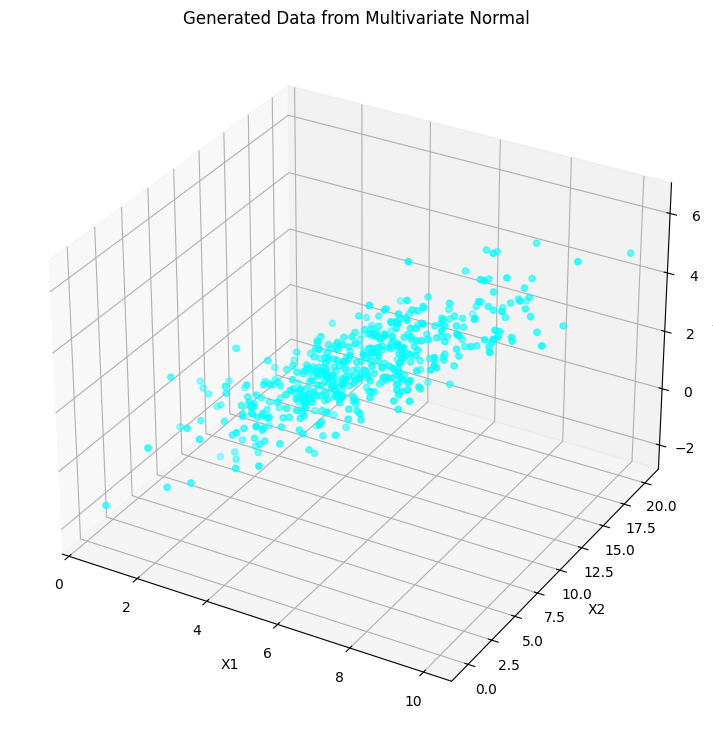

In [18]:
def ex1_1():
    num_samples = 500

    mean = np.array([5, 10, 2])
    covariance = np.array([[3, 2, 2], [2, 10, 1], [2, 1, 2]])

    X = np.random.multivariate_normal(mean=mean, cov=covariance, size=num_samples)
    print(f'X shape: {X.shape}')

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='cyan')
    ax.set_title(f'Generated Data from Multivariate Normal')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    # ax.legend()

    X_centered = X - np.mean(X, axis=0)
    covariance_matrix = np.cov(X_centered, rowvar=False)

    eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

    print(f'Eigen Values: {eigen_values}')
    print(f'Eigen Vectors Shape: {eigen_vectors.shape}')
    print(f'First Eigen Vector Shape: {eigen_vectors[:, 0].shape}')

    return X, eigen_values, eigen_vectors


X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1 = ex1_1()

Cumulative Explained Variance: [0.70899435 0.96890599 1.        ]


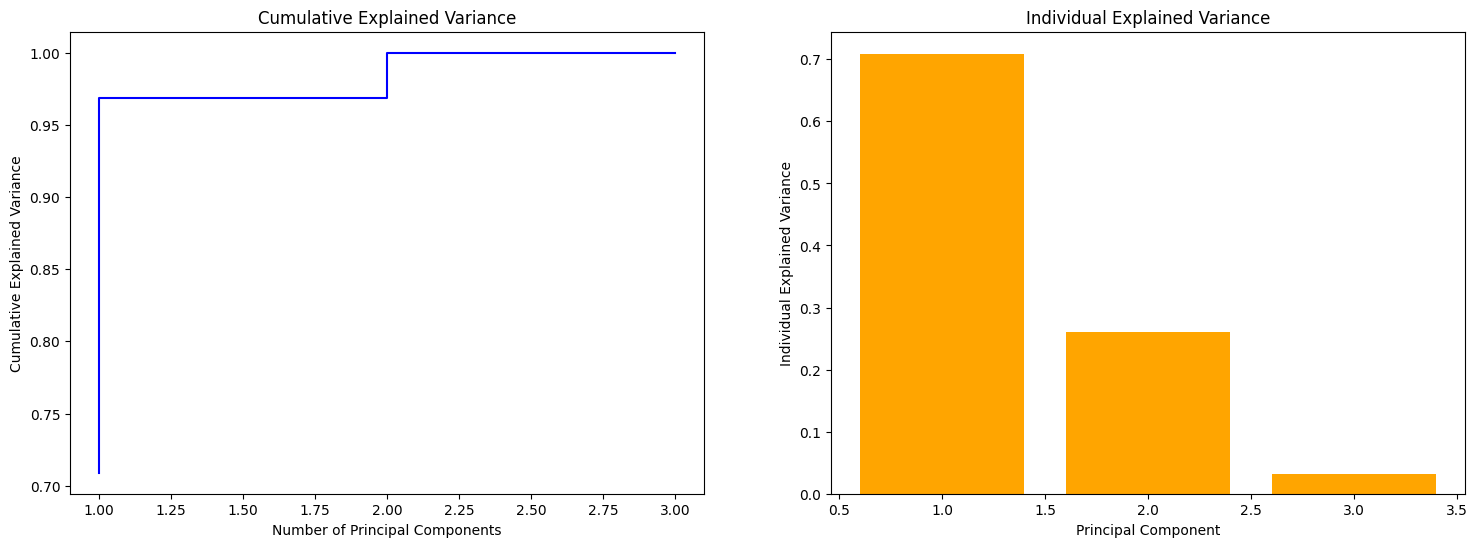

In [ ]:
def ex1_2(eigen_values):
    normalized_eigen_values = eigen_values / np.sum(eigen_values)
    sorted_normalized_eigen_values = np.sort(normalized_eigen_values)[::-1]

    cumulative_explained_variance = np.cumsum(sorted_normalized_eigen_values)

    print(f'Cumulative Explained Variance: {cumulative_explained_variance}')

    _, axes = plt.subplots(1, 2, figsize=(18, 6))
    axes = axes.flatten()

    axes[0].step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, color='blue')
    axes[0].set_title('Cumulative Explained Variance')
    axes[0].set_xlabel('Number of Principal Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    # axes[0].legend()

    axes[1].bar(range(1, len(normalized_eigen_values) + 1), normalized_eigen_values, color='orange')
    axes[1].set_title('Individual Explained Variance')
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Individual Explained Variance')
    # axes[1].legend()

    plt.show()


ex1_2(eigen_values_ex1_1)


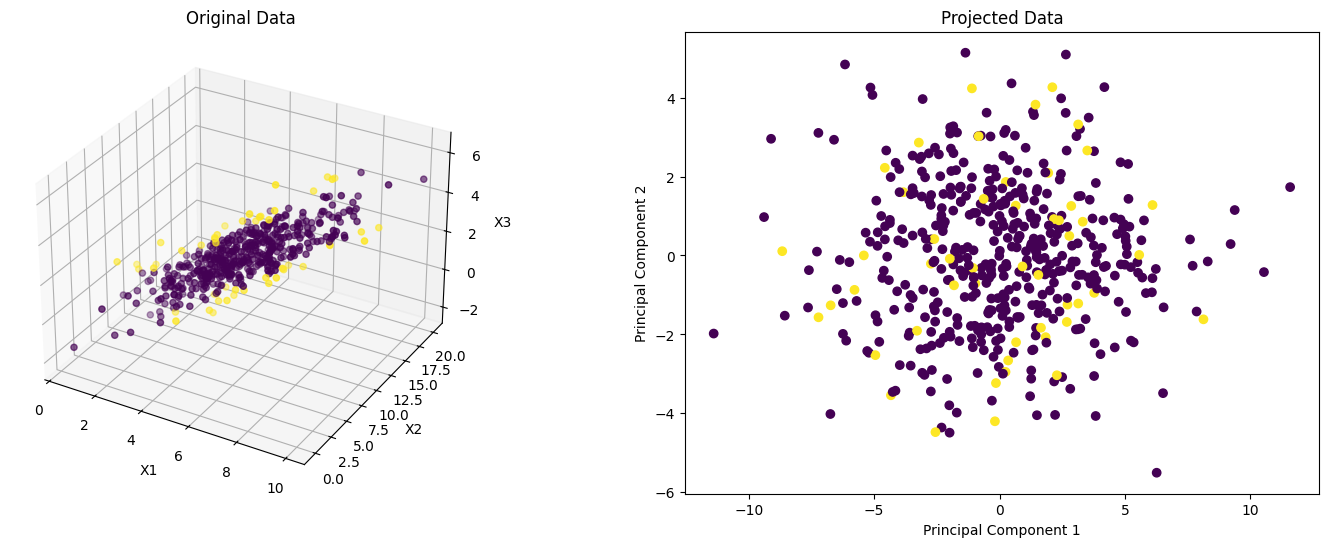

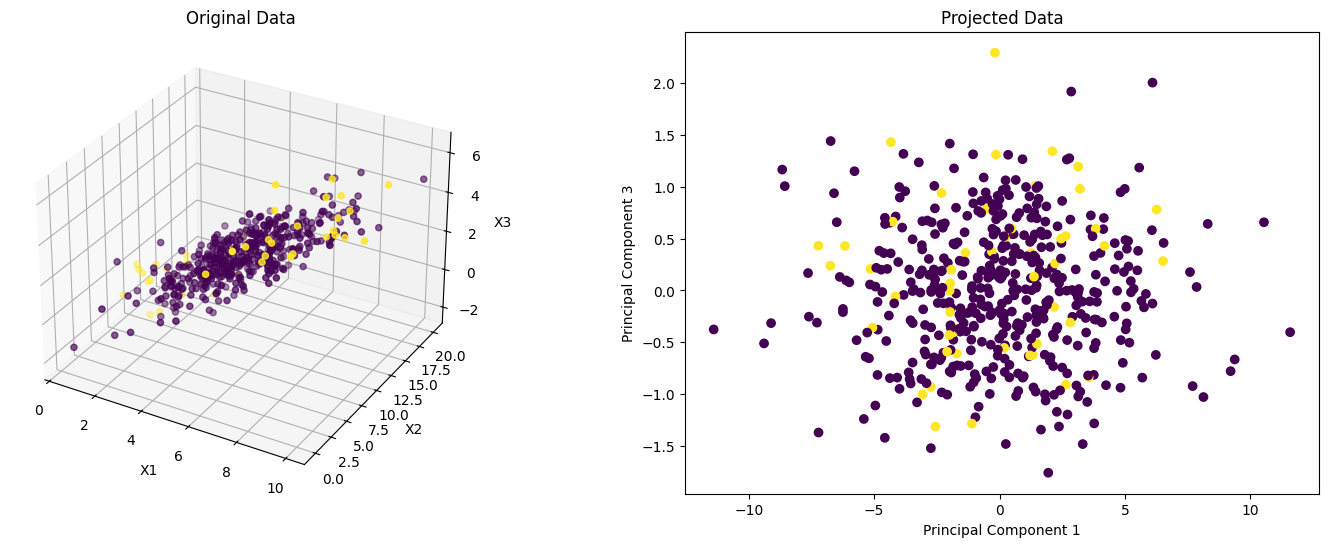

In [26]:
def ex1_3(X, eigen_values, eigen_vectors, idx_principal_component):
    X_centered = X - np.mean(X, axis=0)

    idxs_sorted_eigen_values = np.argsort(eigen_values)[::-1]
    sorted_eigen_values = eigen_values[idxs_sorted_eigen_values]
    sorted_eigen_vectors = eigen_vectors[:, idxs_sorted_eigen_values]

    X_projected = X_centered.dot(sorted_eigen_vectors)
    X_projected_on_principal_component = X_projected[:, idx_principal_component]

    contamination = 0.1
    threshold = np.quantile(np.abs(X_projected_on_principal_component), 1 - contamination)
    outliers = (np.abs(X_projected_on_principal_component) > threshold).astype(int)

    fig = plt.figure(figsize=(18, 6))

    ax_0 = fig.add_subplot(1, 2, 1, projection='3d')
    ax_0.scatter(X[:, 0], X[:, 1], X[:, 2], c=outliers)
    ax_0.set_title(f'Original Data')
    ax_0.set_xlabel('X1')
    ax_0.set_ylabel('X2')
    ax_0.set_zlabel('X3')
    # ax_0.legend()

    remaining_dims = [i for i in range(X.shape[1]) if i != idx_principal_component]

    ax_1 = fig.add_subplot(1, 2, 2)
    ax_1.scatter(X_projected[:, remaining_dims[0]], X_projected[:, remaining_dims[1]], c=outliers)
    ax_1.set_title(f'Projected Data')
    ax_1.set_xlabel(f'Principal Component {remaining_dims[0] + 1}')
    ax_1.set_ylabel(f'Principal Component {remaining_dims[1] + 1}')
    # ax_1.legend()

    plt.show()
    

ex1_3(X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1, 2) # 3rd Principal Component
ex1_3(X_ex1_1, eigen_values_ex1_1, eigen_vectors_ex1_1, 1) # 2nd Principal Component